# Step 03. Exploratory Data Analysis

## Objective

The objective of this notebook is to explore the relationships between well log measurements and lithofacies classes in order to uncover meaningful geological patterns before modeling.

This stage aims to:

- Analyze the distribution of individual petrophysical logs

- Visualize lithofacies class imbalance

- Examine correlations between numerical features

- Identify strongly and weakly correlated log pairs

- Detect potential multicollinearity

- Understand how log responses vary across facies

EDA provides insight into the physical relationships embedded in the dataset and helps guide feature selection and preprocessing strategies.

In [4]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Settings (make plots look clean)
plt.style.use('default')
sns.set_theme(style="whitegrid")

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


## 1. First confirm feature names

In [2]:
import pandas as pd

df = pd.read_csv('facies_data.csv')
df.columns.tolist()


['Facies',
 'Formation',
 'Well Name',
 'Depth',
 'GR',
 'ILD_log10',
 'DeltaPHI',
 'PHIND',
 'PE',
 'NM_M',
 'RELPOS']

## 2. Correlation Heatmap

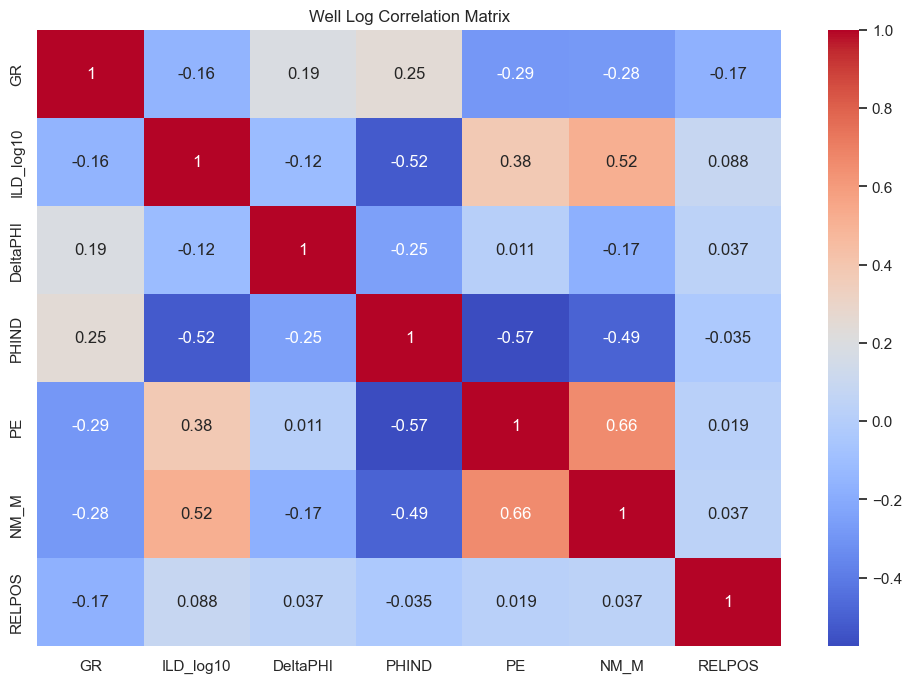

In [5]:
plt.figure(figsize=(12,8))

numeric_cols = ['GR','ILD_log10','DeltaPHI','PHIND','PE','NM_M','RELPOS']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')

plt.title("Well Log Correlation Matrix")
plt.show()


## Well Log Correlation Matrix Interpretation

The correlation matrix was used to examine the linear relationships between well log measurements.
Correlation values range from -1 to 1, where:

- 1 → strong positive relationship

- -1 → strong negative relationship

- 0 → no linear relationship

## Key Observations

**1**. **PE and NM_M (~0.66)**

  - Strong positive correlation

  - These logs provide similar geological information and may be partially redundant.

**2**. **PHIND and PE (~-0.57)**

  - Moderate negative correlation

  - Indicates inverse petrophysical relationship between porosity indicator and photoelectric effect.

**3**. **ILD_log10 and PHIND (~-0.52)**

  - Moderate negative correlation

  - Suggests resistivity decreases as porosity increases, consistent with fluid-filled formations.

**4**. **Most remaining feature pairs (< |0.3|)**

  - Weak correlation

  - Indicates the dataset contains diverse and complementary information useful for machine learning.

## Implication for Modeling

- Low overall multicollinearity in the dataset

- Tree-based models (Random Forest, Gradient Boosting) should perform well

- No immediate need for feature removal

- Features likely capture different rock properties, which helps facies classification

## 3. Log Distribution per Facies

### Gamma Ray vs Facies

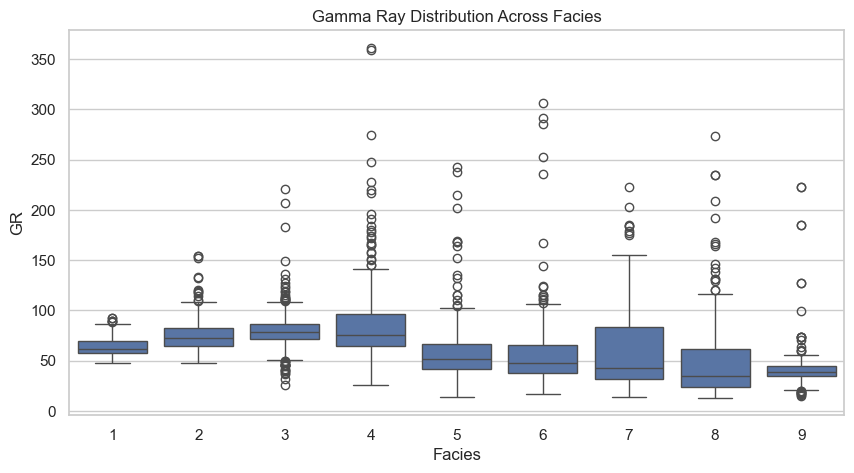

In [6]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Facies', y='GR', data=df)
plt.title("Gamma Ray Distribution Across Facies")
plt.show()


## Gamma Ray Distribution Across Facies

The boxplot shows the variation of Gamma Ray (GR) values across different facies. Gamma Ray measures natural radioactivity and is commonly used to distinguish shale from cleaner formations.

## Observations:

- Some facies (e.g., facies 4) show higher GR values, indicating shale-rich lithology.

- Lower GR facies (e.g., facies 1 and 2) likely represent cleaner reservoir rocks such as sandstones or carbonates.

- Several facies exhibit overlapping GR ranges, indicating that Gamma Ray alone cannot uniquely identify lithology.

- Wide distributions and outliers suggest geological heterogeneity and transitional depositional environments.

## Implication:

Gamma Ray log alone is insufficient for facies classification. Multiple well logs must be combined in a machine learning model to accurately distinguish rock types.

## 4. Resistivity vs Facies

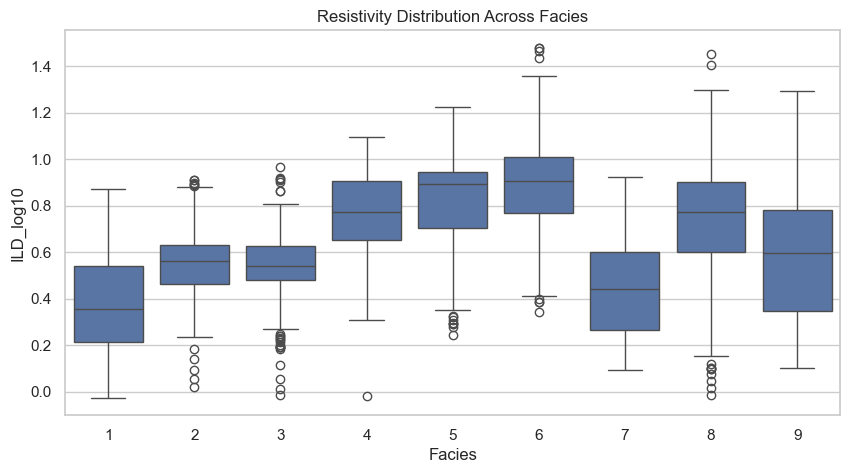

In [7]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Facies', y='ILD_log10', data=df)
plt.title("Resistivity Distribution Across Facies")
plt.show()


## Resistivity Distribution Across Facies

The boxplot shows the distribution of resistivity (ILD_log10) values across facies. Resistivity measures a formation’s ability to resist electrical current and is strongly influenced by fluid content and rock texture.

## Observations:

- Certain facies (e.g., facies 5 and 6) exhibit higher resistivity values, suggesting cleaner or hydrocarbon-bearing formations.

- Lower resistivity facies (e.g., facies 1 and 7) likely represent shale or water-saturated zones.

- Compared to Gamma Ray, the facies show clearer separation, indicating stronger discriminative power.

- Although some overlap remains, resistivity provides significant information for distinguishing lithologies.

## Implication:

Resistivity is a strong predictive feature and is expected to contribute significantly to machine learning-based facies classification.

## 5. Porosity vs Facies

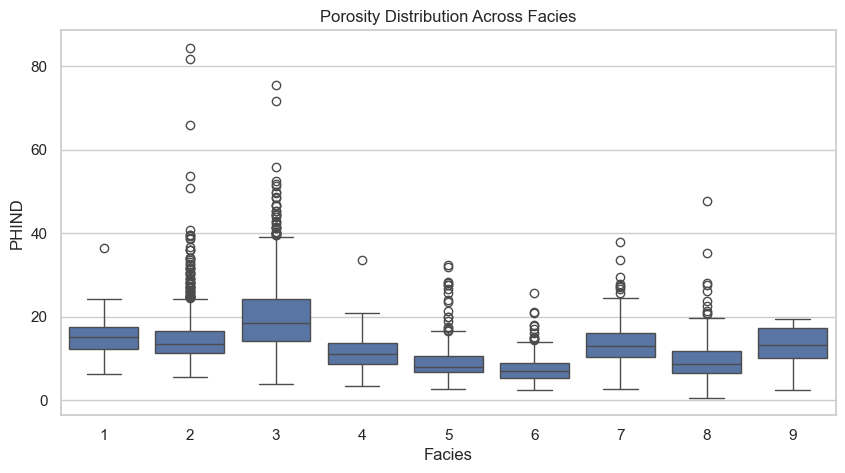

In [8]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Facies', y='PHIND', data=df)
plt.title("Porosity Distribution Across Facies")
plt.show()


## Porosity (PHIND) Distribution Across Facies

The boxplot shows how porosity varies among different facies. Porosity is a key reservoir quality indicator because it reflects the rock’s storage capacity for fluids.

## Observations:

- Facies 3 exhibits the highest porosity values → likely clean, well-sorted reservoir rock (e.g., sandstone).

- Facies 6 shows the lowest porosity → indicative of tight or highly compacted lithology.

- Facies 1, 2, and 7 show moderate porosity → transitional or mixed lithologies.

- There is noticeable overlap between several facies → porosity alone cannot perfectly distinguish lithology.

## Interpretation:

- Higher porosity generally corresponds to better reservoir quality, while lower porosity suggests impermeable or sealing formations.
- The overlap across facies indicates that porosity must be combined with other logs (Gamma Ray, Resistivity, Neutron-Density) for reliable facies classification.

## Machine Learning Implication

**Porosity** is an important predictive feature but not a standalone discriminator.
It contributes to classification when used together with other petrophysical logs, making ML models suitable for capturing the multivariate relationship.

## Conclusion

The exploratory analysis revealed several important patterns:

- The facies classes are imbalanced, with some lithologies significantly more frequent than others.

- Certain logs (e.g., resistivity and porosity indicators) show moderate to strong correlations, indicating possible redundancy.

- Some feature pairs exhibit weak correlation, suggesting they provide complementary information to the model.

- Log distributions vary meaningfully across facies, confirming that petrophysical measurements contain predictive geological signals.

Overall, EDA confirmed that lithofacies classification is influenced by multivariate and nonlinear interactions among logs, justifying the use of advanced machine learning models such as Random Forest.